# Adjoint + NN Hybrid Method for PDE-Constrained Optimization

This notebook demonstrates the **Adjoint + Neural Network** hybrid approach for estimating unknown source terms in heat equations.

**Key Idea**: Combine the adjoint method (efficient PDE gradient computation) with neural network parameterization (implicit regularization + spectral control).

$$
\nabla_\theta J = \underbrace{\left(\frac{\partial f}{\partial \theta}\right)^T}_{\text{JAX autodiff}} \cdot \underbrace{\nabla_f J}_{\text{adjoint method}}
$$

## Contents
1. [Problem Setup & Visualization](#1-problem-setup)
2. [Pure Adjoint Baseline](#2-pure-adjoint)
3. [Gradient Verification](#3-gradient-verification)
4. [Adjoint + NN Training](#4-adjoint-nn)
5. [High-Frequency Challenge](#5-high-frequency)
6. [Comparison Summary](#6-comparison)

## Recent Updates (February 24, 2026)
- **Scheme-aware Pure Adjoint updates fixed**: implicit now updates `f[1:, 1:-1]`, explicit updates `f[:-1, 1:-1]`.
- **Baseline script save path fixed**: output now writes to project-relative `results/` instead of a hardcoded machine path.
- **Lazy imports in `src/__init__.py`**: numpy-only modules import without requiring JAX/Flax.



In [1]:
import sys
from pathlib import Path

# Robust path setup: works whether notebook is launched from repo root
# or from 1_Adjoint_Method/notebooks/
cwd = Path.cwd().resolve()
if cwd.name == 'notebooks':
    project_root = cwd.parent
else:
    project_root = cwd

src_path = project_root / 'src'
if not src_path.exists():
    raise FileNotFoundError(f'Cannot find src directory at: {src_path}')

sys.path.insert(0, str(src_path))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

import jax
import jax.numpy as jnp
jax.config.update('jax_enable_x64', True)

print(f'JAX version: {jax.__version__}')
print(f'Devices: {jax.devices()}')
print(f'Project root: {project_root}')

# Our modules
from problems import get_problem, PROBLEMS
from pde_adjoint_solver import forward_solve, adjoint_solve, adjoint_optimize
from adjoint_nn import (
    make_pde_solver_vjp, discrete_adjoint_gradient,
    create_model, nn_to_grid, train_adjoint_nn, verify_gradient,
    plot_comparison
)

plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})
print(f'Available problems: {list(PROBLEMS.keys())}')



JAX version: 0.9.0.1
Devices: [CpuDevice(id=0)]
Project root: /Users/handsomedoge/Desktop/PDE/1_Adjoint_Method
Available problems: ['problem1', 'problem2', 'problem3', 'high-osci']


---
## 1. Problem Setup & Visualization <a id='1-problem-setup'></a>

We solve the **1D heat equation inverse problem**: given observed solution $u_{\text{obs}}(x,t)$, recover the unknown source $f(x,t)$.

$$
\frac{\partial u}{\partial t} - \alpha \frac{\partial^2 u}{\partial x^2} = f(x,t), \quad x \in [0, L], \; t \in [0, T]
$$

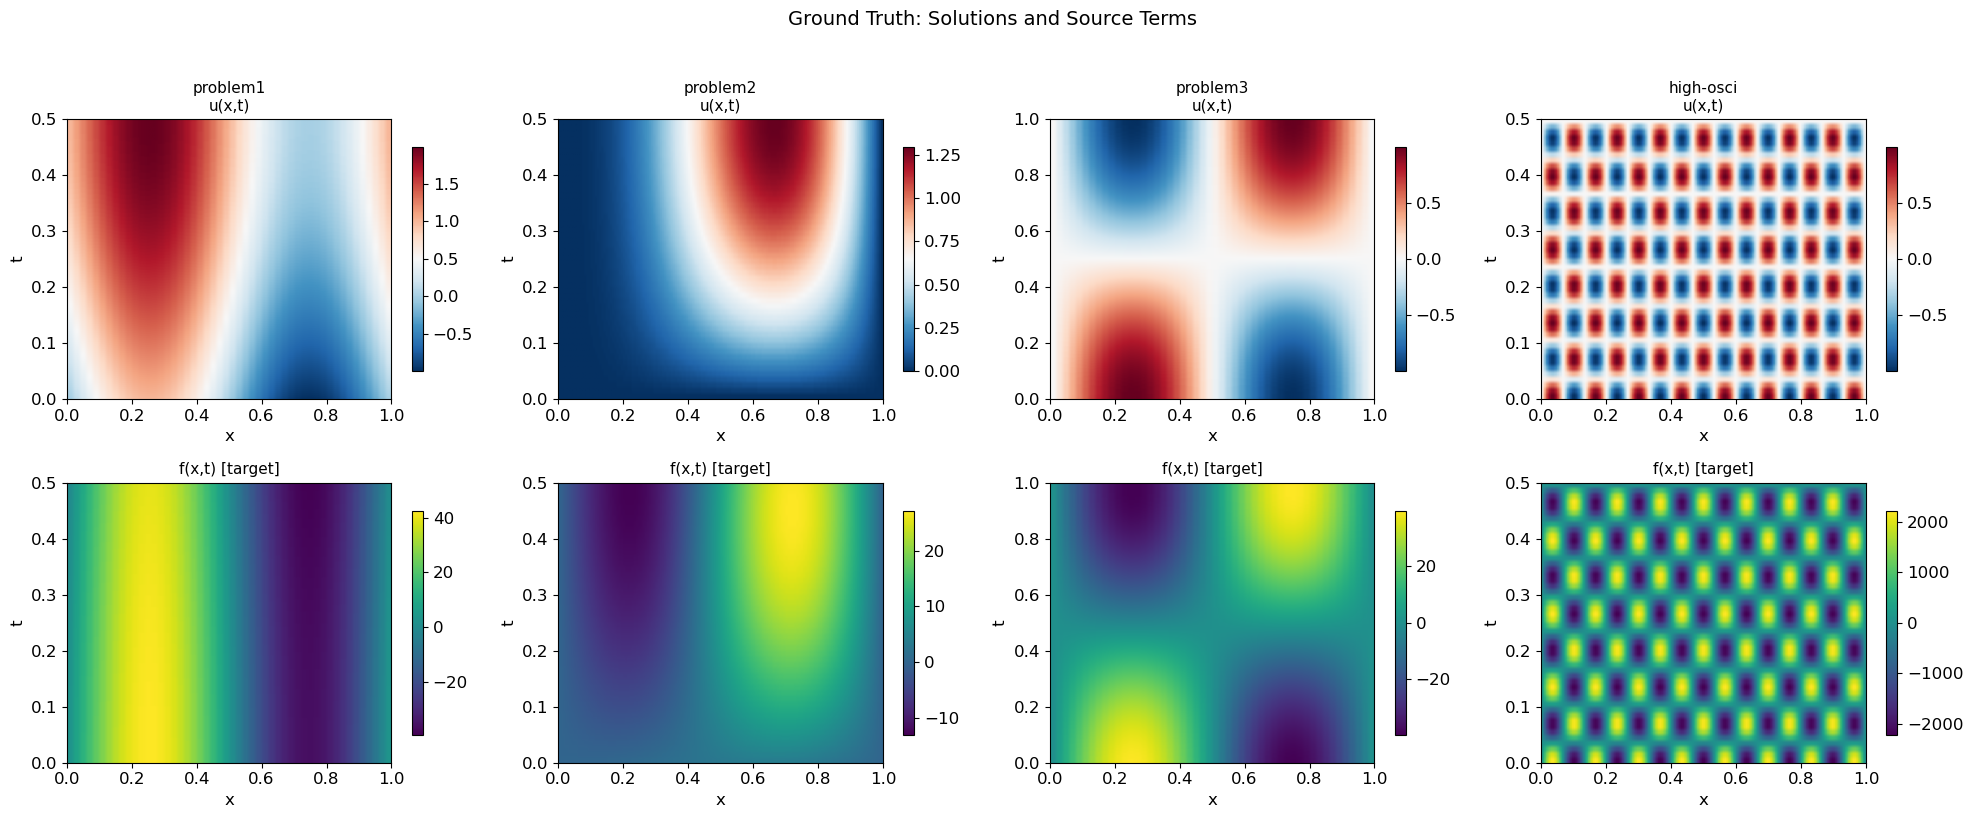

Problem1
  Domain: x ∈ [0, 1.0], t ∈ [0, 0.5]
  Grid:   50 × 5000  (dx=2.0408e-02, dt=1.0002e-04)
  Scheme: explicit  |  CFL = 0.2401
  Alpha:  1.0

Problem2
  Domain: x ∈ [0, 1.0], t ∈ [0, 0.5]
  Grid:   150 × 50  (dx=6.7114e-03, dt=1.0204e-02)
  Scheme: implicit  |  CFL = 226.5408
  Alpha:  1.0

Problem3
  Domain: x ∈ [0, 1.0], t ∈ [0, 1.0]
  Grid:   50 × 10000  (dx=2.0408e-02, dt=1.0001e-04)
  Scheme: explicit  |  CFL = 0.2401
  Alpha:  1.0

HighOscillatory
  Domain: x ∈ [0, 1.0], t ∈ [0, 0.5]
  Grid:   200 × 50  (dx=5.0251e-03, dt=1.0204e-02)
  Scheme: implicit  |  CFL = 404.0918
  Alpha:  1.0



In [2]:
# Load all problems and visualize their ground truth
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for idx, name in enumerate(['problem1', 'problem2', 'problem3', 'high-osci']):
    prob = get_problem(name)
    
    # True solution u(x,t)
    im0 = axes[0, idx].imshow(prob.u_true, aspect='auto',
                               extent=[0, prob.L, 0, prob.T_final],
                               origin='lower', cmap='RdBu_r')
    axes[0, idx].set_title(f'{name}\nu(x,t)', fontsize=11)
    axes[0, idx].set_xlabel('x'); axes[0, idx].set_ylabel('t')
    plt.colorbar(im0, ax=axes[0, idx], shrink=0.8)
    
    # True source f(x,t)
    im1 = axes[1, idx].imshow(prob.f_true, aspect='auto',
                               extent=[0, prob.L, 0, prob.T_final],
                               origin='lower', cmap='viridis')
    axes[1, idx].set_title(f'f(x,t) [target]', fontsize=11)
    axes[1, idx].set_xlabel('x'); axes[1, idx].set_ylabel('t')
    plt.colorbar(im1, ax=axes[1, idx], shrink=0.8)

fig.suptitle('Ground Truth: Solutions and Source Terms', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print problem summaries
for name in ['problem1', 'problem2', 'problem3', 'high-osci']:
    prob = get_problem(name)
    print(prob.summary())
    print()

---
## 2. Pure Adjoint Baseline <a id='2-pure-adjoint'></a>

The pure adjoint method optimizes $f$ directly on the grid:

1. **Forward solve**: $u = \text{solve}(f)$
2. **Compute misfit**: $r = u - u_{\text{obs}}$
3. **Adjoint solve**: $-p_t - \alpha p_{xx} = r$ (backward in time)
4. **Gradient descent**: $f \leftarrow f - \eta \cdot (\lambda f + p)$

**Note on time indexing**: The gradient update is applied only to *active* time indices — for implicit (Backward Euler), $f$ at $n=1,\dots,N_t{-}1$ drives the solve; for explicit (Forward Euler), $f$ at $n=0,\dots,N_t{-}2$. Boundary spatial points are also excluded (Dirichlet BCs).

In [ ]:
# Run pure adjoint on Problem 2
prob = get_problem('problem2')
print(prob.summary())
print()

f_adj, losses_adj = adjoint_optimize(
    f_init=np.zeros((prob.nt, prob.nx)),
    u_obs=prob.u_obs, u0=prob.u0,
    bc_left=prob.bc_left, bc_right=prob.bc_right,
    alpha=prob.alpha, dx=prob.dx, dt=prob.dt,
    nx=prob.nx, nt=prob.nt,
    lr=5.0, max_iter=3000, scheme='implicit',
    log_every=500,
)

print(f'\nFinal loss: {losses_adj[-1]:.6e}')

Problem2
  Domain: x ∈ [0, 1.0], t ∈ [0, 0.5]
  Grid:   150 × 50  (dx=6.7114e-03, dt=1.0204e-02)
  Scheme: implicit  |  CFL = 226.5408
  Alpha:  1.0

  Iter     0/3000: loss = 7.971939e-02
  Iter   500/3000: loss = 9.980281e-04
  Iter  1000/3000: loss = 1.693918e-04
  Iter  1500/3000: loss = 9.086052e-05
  Iter  2000/3000: loss = 7.056820e-05
  Iter  2500/3000: loss = 6.128331e-05
  Iter  3000/3000: loss = 5.630476e-05

Final loss: 5.630476e-05


In [ ]:

f_adj, losses_adj = adjoint_optimize(
    f_init=np.zeros((prob.nt, prob.nx)),
    u_obs=prob.u_obs, u0=prob.u0,
    bc_left=prob.bc_left, bc_right=prob.bc_right,
    alpha=prob.alpha, dx=prob.dx, dt=prob.dt,
    nx=prob.nx, nt=prob.nt,
    lr=5.0, max_iter=3000, scheme='implicit',
    log_every=500,
)

print(f'\nFinal loss: {losses_adj[-1]:.6e}')

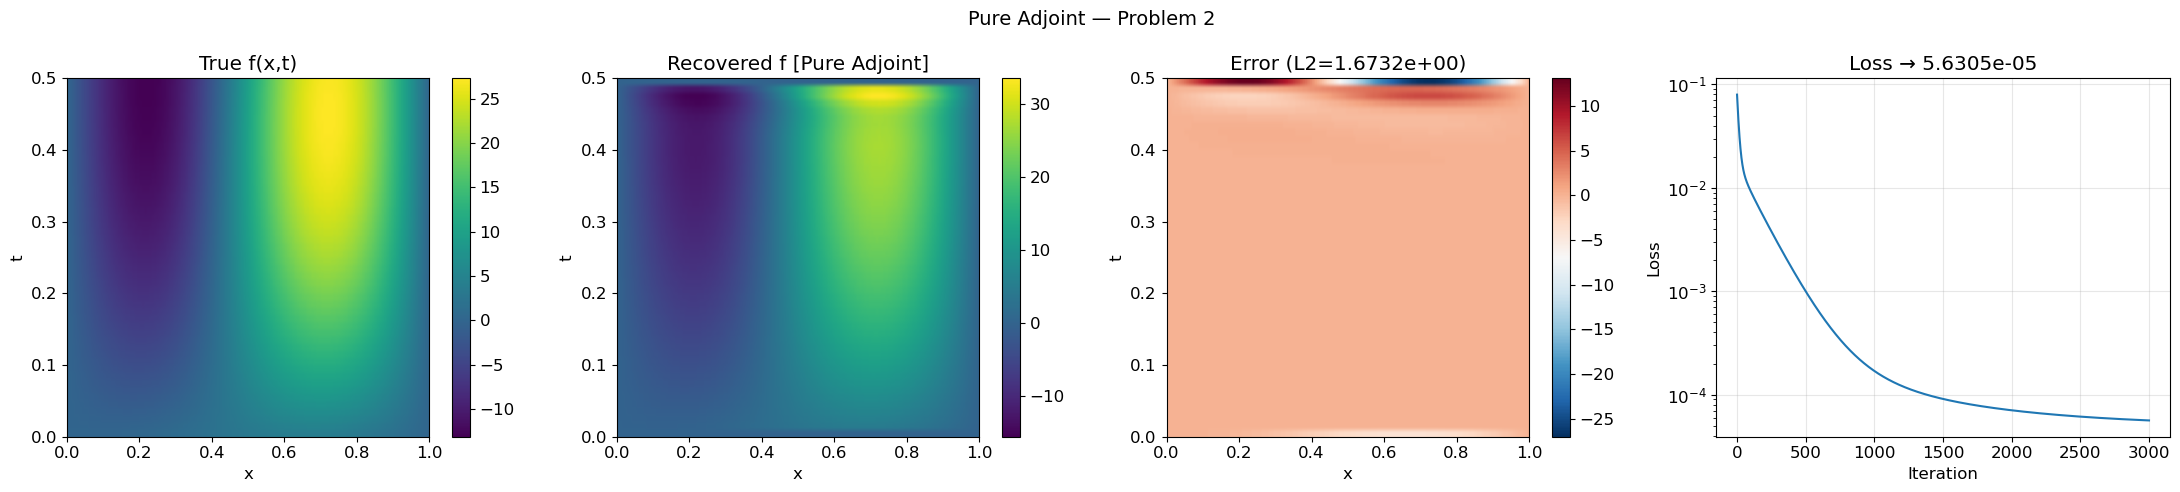

In [ ]:
# Visualize pure adjoint result
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
extent = [0, prob.L, 0, prob.T_final]

im = axes[0].imshow(prob.f_true, aspect='auto', extent=extent, origin='lower', cmap='viridis')
axes[0].set_title('True f(x,t)'); axes[0].set_xlabel('x'); axes[0].set_ylabel('t')
plt.colorbar(im, ax=axes[0])

im = axes[1].imshow(f_adj, aspect='auto', extent=extent, origin='lower', cmap='viridis')
axes[1].set_title('Recovered f [Pure Adjoint]'); axes[1].set_xlabel('x'); axes[1].set_ylabel('t')
plt.colorbar(im, ax=axes[1])

error = f_adj - prob.f_true
im = axes[2].imshow(error, aspect='auto', extent=extent, origin='lower', cmap='RdBu_r')
l2_err = np.sqrt(np.sum(error**2) * prob.dx * prob.dt)
axes[2].set_title(f'Error (L2={l2_err:.4e})'); axes[2].set_xlabel('x'); axes[2].set_ylabel('t')
plt.colorbar(im, ax=axes[2])

axes[3].semilogy(losses_adj, lw=1.5)
axes[3].set_title(f'Loss → {losses_adj[-1]:.4e}'); axes[3].set_xlabel('Iteration'); axes[3].set_ylabel('Loss')
axes[3].grid(True, alpha=0.3)

plt.suptitle('Pure Adjoint — Problem 2', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Run pure adjoint on high-osci
prob = get_problem('high-osci')
print(prob.summary())
print()

f_adj, losses_adj = adjoint_optimize(
    f_init=np.zeros((prob.nt, prob.nx)),
    u_obs=prob.u_obs, u0=prob.u0,
    bc_left=prob.bc_left, bc_right=prob.bc_right,
    alpha=prob.alpha, dx=prob.dx, dt=prob.dt,
    nx=prob.nx, nt=prob.nt,
    lr=5.0, max_iter=3000, scheme='implicit',
    log_every=500,
)

print(f'\nFinal loss: {losses_adj[-1]:.6e}')

In [ ]:
# Visualize pure adjoint result
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
extent = [0, prob.L, 0, prob.T_final]

im = axes[0].imshow(prob.f_true, aspect='auto', extent=extent, origin='lower', cmap='viridis')
axes[0].set_title('True f(x,t)'); axes[0].set_xlabel('x'); axes[0].set_ylabel('t')
plt.colorbar(im, ax=axes[0])

im = axes[1].imshow(f_adj, aspect='auto', extent=extent, origin='lower', cmap='viridis')
axes[1].set_title('Recovered f [Pure Adjoint]'); axes[1].set_xlabel('x'); axes[1].set_ylabel('t')
plt.colorbar(im, ax=axes[1])

error = f_adj - prob.f_true
im = axes[2].imshow(error, aspect='auto', extent=extent, origin='lower', cmap='RdBu_r')
l2_err = np.sqrt(np.sum(error**2) * prob.dx * prob.dt)
axes[2].set_title(f'Error (L2={l2_err:.4e})'); axes[2].set_xlabel('x'); axes[2].set_ylabel('t')
plt.colorbar(im, ax=axes[2])

axes[3].semilogy(losses_adj, lw=1.5)
axes[3].set_title(f'Loss → {losses_adj[-1]:.4e}'); axes[3].set_xlabel('Iteration'); axes[3].set_ylabel('Loss')
axes[3].grid(True, alpha=0.3)

plt.suptitle('Pure Adjoint — High Oscillation', fontsize=14)
plt.tight_layout()
plt.show()

---
## 3. Gradient Verification <a id='3-gradient-verification'></a>

Before trusting the Adjoint+NN pipeline, we verify that the **discrete adjoint gradient** exactly matches **finite differences**.

This is critical because the `custom_vjp` backward pass must implement the *discrete* adjoint (discretize-then-optimize), not the *continuous* adjoint (optimize-then-discretize). Only the discrete version gives exact $\partial J / \partial f$.

**Discrete adjoint equations** (Backward Euler):
$$
A \, \mu_{N_t{-}1} = -r_{N_t{-}1} \, \Delta x \, \Delta t, \qquad
A \, \mu_n = \mu_{n+1} - r_n \, \Delta x \, \Delta t \;\; (n < N_t{-}1)
$$
$$
\frac{\partial J}{\partial f_m} = -\Delta t \, \mu_m
$$

The continuous adjoint ($-p_t - \alpha p_{xx} = r$) differs by scaling factors and a time-index shift — acceptable for pure adjoint gradient descent (the learning rate absorbs the difference), but **incorrect** for `custom_vjp` where the gradient must be exact.

In [5]:
# Gradient verification on Problem 2
print('=== Problem 2 ===')
err_p2 = verify_gradient('problem2', n_checks=5, eps=1e-5)

print('\n=== High-Oscillatory (ω=15) ===')
err_ho = verify_gradient('high-osci', n_checks=5, eps=1e-5)

=== Problem 2 ===
Gradient verification on problem2 (coarse: 20×10)
  Index             Adjoint           FD      Rel Err
  ------------ ------------ ------------ ------------
  ( 5,14)     -1.969286e-04 -1.969286e-04 4.488370e-09
  ( 4,10)     -2.177691e-04 -2.177691e-04 6.524314e-10
  ( 3, 2)     -4.912495e-05 -4.912495e-05 4.591069e-10
  ( 8, 4)     -7.303145e-05 -7.303145e-05 1.227006e-08
  ( 4,17)     -8.546785e-05 -8.546784e-05 1.408012e-08

  Max relative error: 1.408012e-08  [PASS]

=== High-Oscillatory (ω=15) ===
Gradient verification on high-osci (coarse: 20×10)
  Index             Adjoint           FD      Rel Err
  ------------ ------------ ------------ ------------
  ( 5,14)     8.896699e-08 8.896633e-08 7.392873e-06
  ( 4,10)     -5.628578e-07 -5.628581e-07 4.666353e-07
  ( 3, 2)     -4.849649e-08 -4.849628e-08 4.484931e-06
  ( 8, 4)     -6.160273e-07 -6.160277e-07 6.690127e-07
  ( 4,17)     -1.114435e-06 -1.114435e-06 1.521038e-07

  Max relative error: 7.392873e-06  [PA

---
## 4. Adjoint + NN Training <a id='4-adjoint-nn'></a>

Now we parameterize $f(x,t) = \text{NN}(x, t; \theta)$ and optimize $\theta$ using:

$$
\nabla_\theta J = \left(\frac{\partial f}{\partial \theta}\right)^T \cdot \nabla_f J
$$

where $\nabla_f J$ comes from the discrete adjoint, and $\partial f / \partial \theta$ comes from JAX autodiff through the Flax network.

### Architecture: SourceMLP
```
Input (x, t) → Dense(128) → tanh → Dense(128) → tanh → Dense(128) → tanh → Dense(1)
```

In [6]:
# Train Adjoint+NN (MLP) on Problem 2
res_p2_mlp = train_adjoint_nn(
    problem_name='problem2',
    arch='mlp',
    lr=1e-3,
    max_iter=3000,
    log_every=500,
)

Problem2
  Domain: x ∈ [0, 1.0], t ∈ [0, 0.5]
  Grid:   150 × 50  (dx=6.7114e-03, dt=1.0204e-02)
  Scheme: implicit  |  CFL = 226.5408
  Alpha:  1.0
  Arch: mlp, LR: 0.001, Iters: 3000

  Iter     0/3000: loss = 7.970267e-02
  Iter   500/3000: loss = 1.798819e-04
  Iter  1000/3000: loss = 4.364862e-05
  Iter  1500/3000: loss = 2.077199e-05
  Iter  2000/3000: loss = 1.244697e-05
  Iter  2500/3000: loss = 1.612013e-05
  Iter  3000/3000: loss = 5.980717e-06


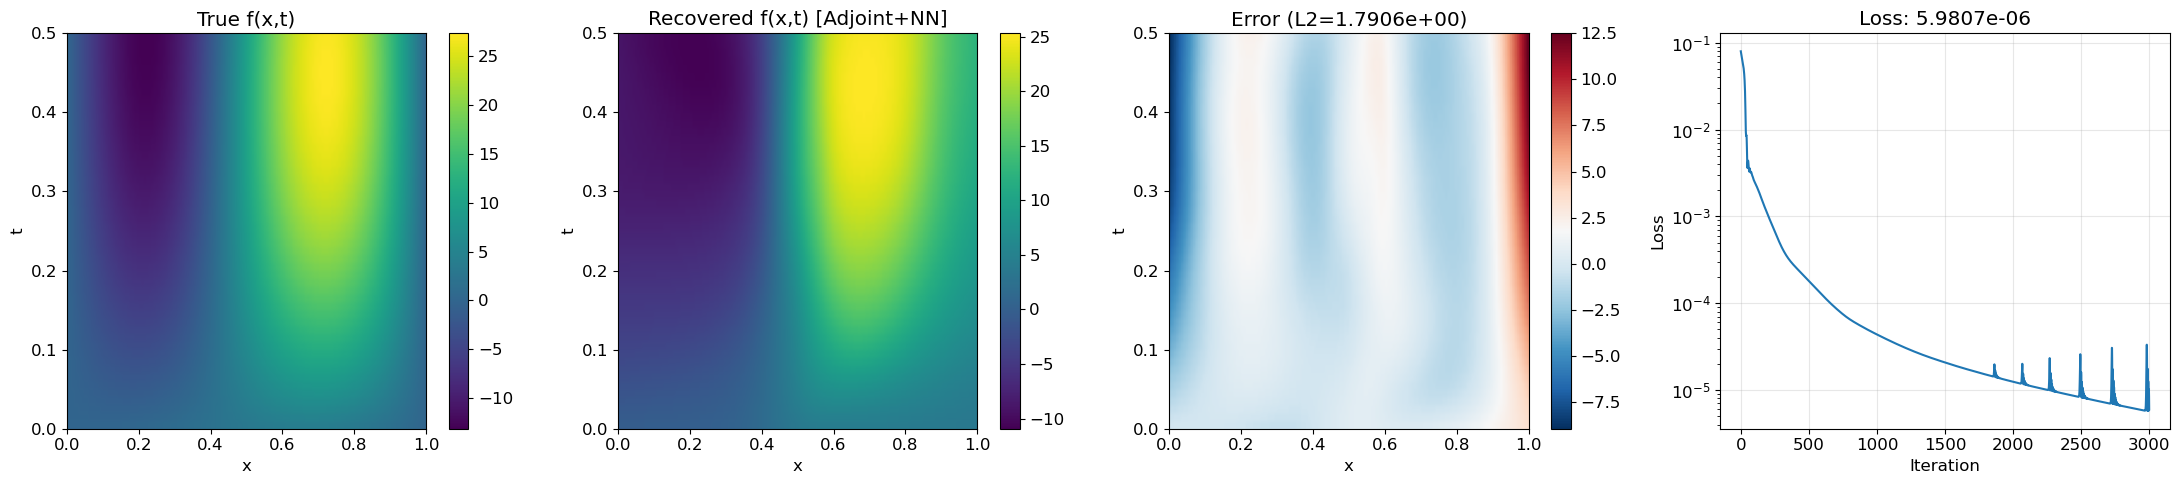

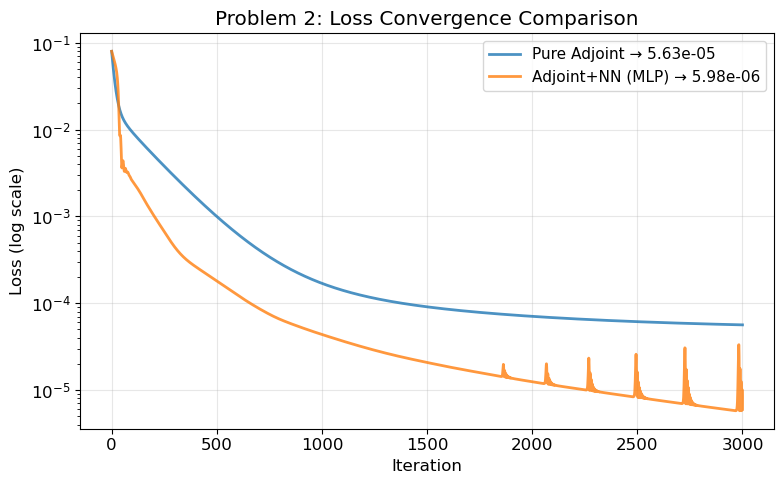


Pure Adjoint final loss:  5.630476e-05
Adjoint+NN final loss:    5.980717e-06
Improvement factor:       9.4×


In [7]:
# Visualize Adjoint+NN result
plot_comparison(res_p2_mlp, save_path=None)

# Side-by-side loss comparison
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(losses_adj, lw=2, label=f'Pure Adjoint → {losses_adj[-1]:.2e}', alpha=0.8)
ax.semilogy(res_p2_mlp['losses'], lw=2, label=f'Adjoint+NN (MLP) → {res_p2_mlp["losses"][-1]:.2e}', alpha=0.8)
ax.set_xlabel('Iteration'); ax.set_ylabel('Loss (log scale)')
ax.set_title('Problem 2: Loss Convergence Comparison')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nPure Adjoint final loss:  {losses_adj[-1]:.6e}')
print(f'Adjoint+NN final loss:    {res_p2_mlp["losses"][-1]:.6e}')
print(f'Improvement factor:       {losses_adj[-1] / res_p2_mlp["losses"][-1]:.1f}×')

---
## 5. High-Frequency Challenge (ω=15) <a id='5-high-frequency'></a>

Standard MLPs suffer from **spectral bias** — they learn low frequencies first and struggle with high-frequency targets. We compare three architectures:

| Architecture | Key Idea | Why It Helps |
|---|---|---|
| **MLP** | Standard tanh layers | Baseline (spectral bias) |
| **FourierMLP** | Random Fourier feature input encoding | Projects inputs into frequency space, `scale ≈ ω` |
| **SIREN** | sin(ω₀ · Wx + b) activation | Periodic activations naturally represent oscillations |

In [8]:
# --- MLP on high-osci ---
print('=== Adjoint + MLP ===')
res_ho_mlp = train_adjoint_nn(
    problem_name='high-osci',
    arch='mlp',
    model_kwargs={'hidden_dims': (256, 256, 256)},
    lr=1e-3, max_iter=5000, log_every=1000,
)

=== Adjoint + MLP ===
HighOscillatory
  Domain: x ∈ [0, 1.0], t ∈ [0, 0.5]
  Grid:   200 × 50  (dx=5.0251e-03, dt=1.0204e-02)
  Scheme: implicit  |  CFL = 404.0918
  Alpha:  1.0
  Arch: mlp, LR: 0.001, Iters: 5000

  Iter     0/5000: loss = 6.104771e-02
  Iter  1000/5000: loss = 6.103172e-02
  Iter  2000/5000: loss = 6.103169e-02
  Iter  3000/5000: loss = 6.103167e-02
  Iter  4000/5000: loss = 6.103163e-02
  Iter  5000/5000: loss = 6.103153e-02


In [9]:
# --- FourierMLP on high-osci ---
print('=== Adjoint + Fourier MLP ===')
res_ho_fourier = train_adjoint_nn(
    problem_name='high-osci',
    arch='fourier',
    model_kwargs={
        'hidden_dims': (256, 256, 256),
        'num_frequencies': 128,
        'frequency_scale': 15.0,  # Match target ω
    },
    lr=1e-3, max_iter=5000, log_every=1000,
)

=== Adjoint + Fourier MLP ===
HighOscillatory
  Domain: x ∈ [0, 1.0], t ∈ [0, 0.5]
  Grid:   200 × 50  (dx=5.0251e-03, dt=1.0204e-02)
  Scheme: implicit  |  CFL = 404.0918
  Alpha:  1.0
  Arch: fourier, LR: 0.001, Iters: 5000

  Iter     0/5000: loss = 6.103291e-02
  Iter  1000/5000: loss = 4.754895e-02
  Iter  2000/5000: loss = 4.616171e-02
  Iter  3000/5000: loss = 3.756586e-02
  Iter  4000/5000: loss = 2.800006e-02
  Iter  5000/5000: loss = 1.957619e-02


In [10]:
# --- SIREN on high-osci ---
print('=== Adjoint + SIREN ===')
res_ho_siren = train_adjoint_nn(
    problem_name='high-osci',
    arch='siren',
    model_kwargs={
        'hidden_dims': (256, 256, 256),
        'omega_0': 30.0,
    },
    lr=1e-4, max_iter=5000, log_every=1000,
)

=== Adjoint + SIREN ===
HighOscillatory
  Domain: x ∈ [0, 1.0], t ∈ [0, 0.5]
  Grid:   200 × 50  (dx=5.0251e-03, dt=1.0204e-02)
  Scheme: implicit  |  CFL = 404.0918
  Alpha:  1.0
  Arch: siren, LR: 0.0001, Iters: 5000

  Iter     0/5000: loss = 6.103305e-02
  Iter  1000/5000: loss = 5.901217e-02
  Iter  2000/5000: loss = 5.752511e-02
  Iter  3000/5000: loss = 5.588476e-02
  Iter  4000/5000: loss = 8.239211e-02
  Iter  5000/5000: loss = 5.828941e-02


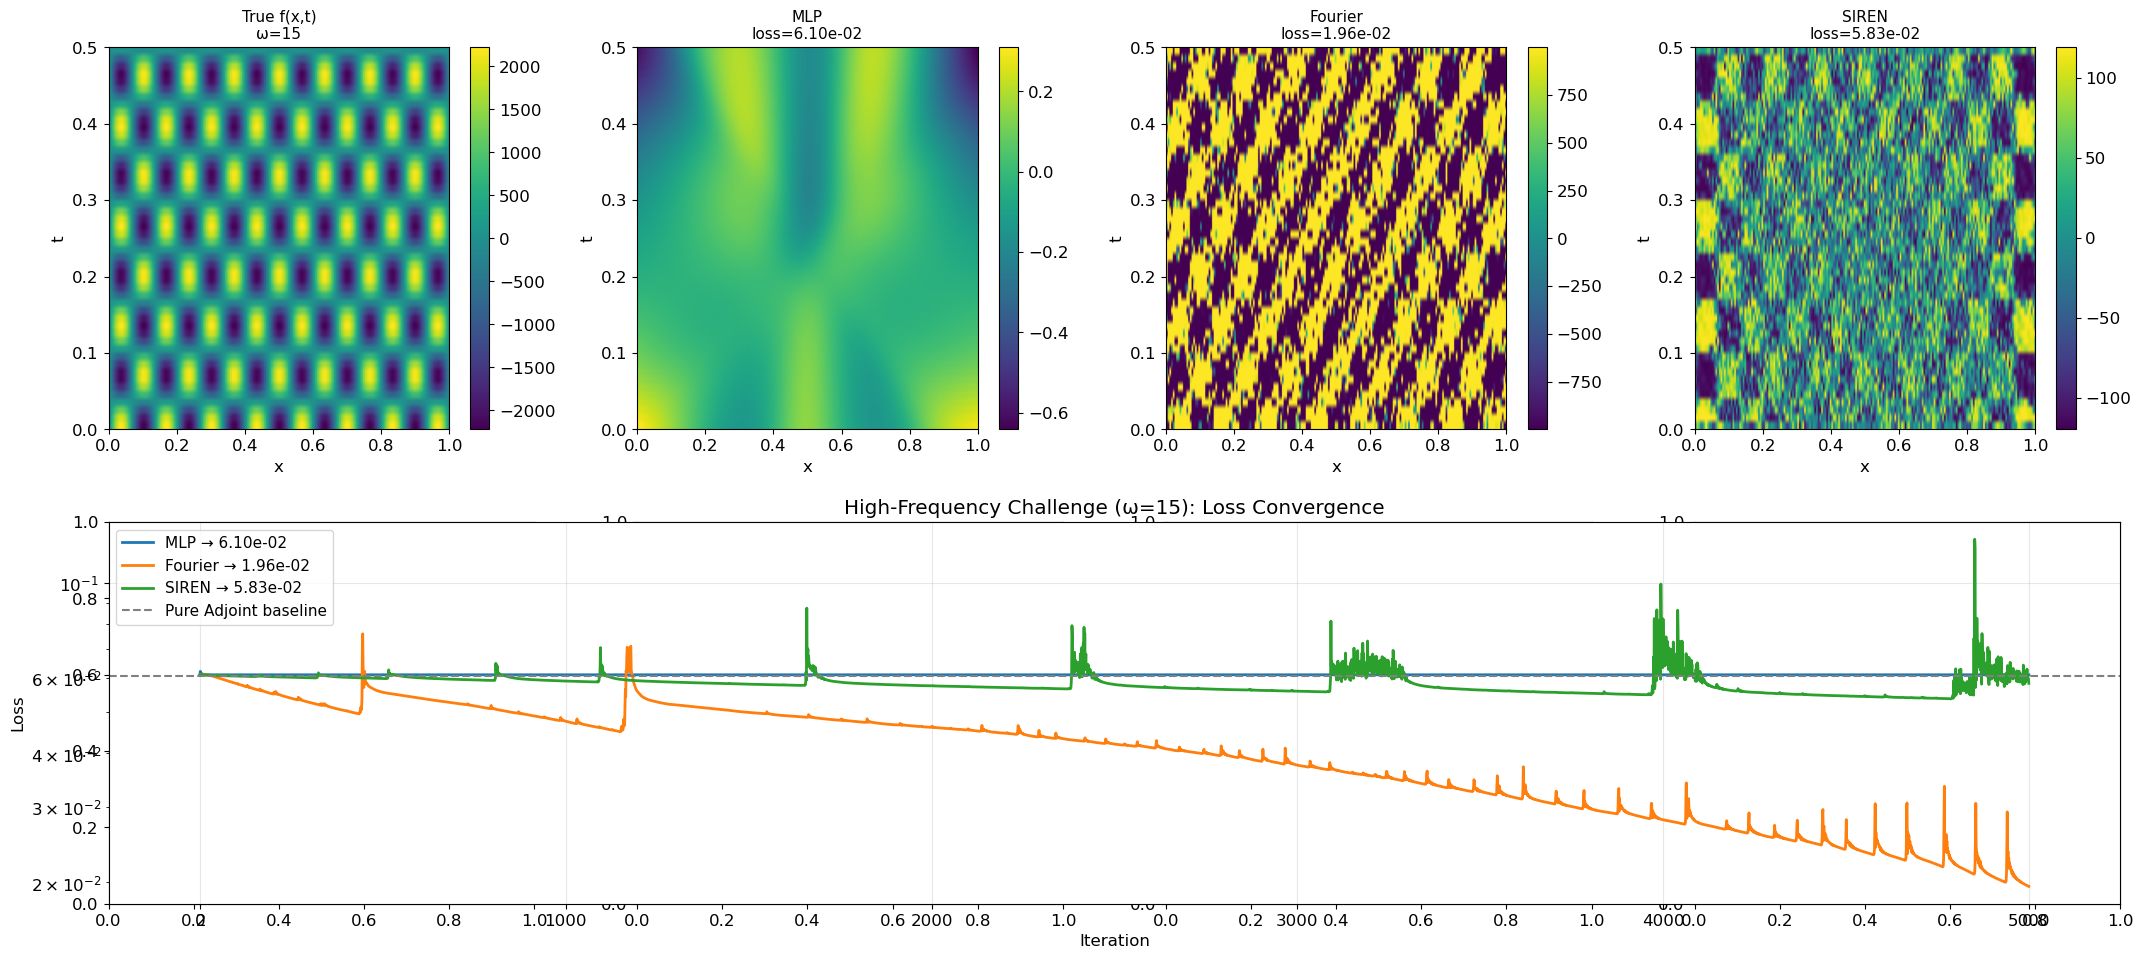

In [11]:
# Compare all architectures on high-osci
fig, axes = plt.subplots(2, 4, figsize=(22, 10))

prob_ho = get_problem('high-osci')
extent = [0, prob_ho.L, 0, prob_ho.T_final]

# Row 1: True f + recovered f for each architecture
im = axes[0, 0].imshow(prob_ho.f_true, aspect='auto', extent=extent, origin='lower', cmap='viridis')
axes[0, 0].set_title('True f(x,t)\nω=15', fontsize=11)
axes[0, 0].set_xlabel('x'); axes[0, 0].set_ylabel('t')
plt.colorbar(im, ax=axes[0, 0])

for idx, (name, res) in enumerate([
    ('MLP', res_ho_mlp), ('Fourier', res_ho_fourier), ('SIREN', res_ho_siren)
]):
    im = axes[0, idx+1].imshow(res['f_opt'], aspect='auto', extent=extent, origin='lower', cmap='viridis')
    axes[0, idx+1].set_title(f'{name}\nloss={res["losses"][-1]:.2e}', fontsize=11)
    axes[0, idx+1].set_xlabel('x'); axes[0, idx+1].set_ylabel('t')
    plt.colorbar(im, ax=axes[0, idx+1])

# Row 2: Loss curves
ax_loss = plt.subplot(2, 1, 2)
ax_loss.semilogy(res_ho_mlp['losses'], lw=2, label=f'MLP → {res_ho_mlp["losses"][-1]:.2e}')
ax_loss.semilogy(res_ho_fourier['losses'], lw=2, label=f'Fourier → {res_ho_fourier["losses"][-1]:.2e}')
ax_loss.semilogy(res_ho_siren['losses'], lw=2, label=f'SIREN → {res_ho_siren["losses"][-1]:.2e}')
ax_loss.axhline(y=6.05e-2, color='gray', ls='--', lw=1.5, label='Pure Adjoint baseline')
ax_loss.set_xlabel('Iteration'); ax_loss.set_ylabel('Loss')
ax_loss.set_title('High-Frequency Challenge (ω=15): Loss Convergence')
ax_loss.legend(fontsize=11); ax_loss.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. Comparison Summary <a id='6-comparison'></a>

In [12]:
# Summary table
print('=' * 70)
print('  RESULTS SUMMARY')
print('=' * 70)

print('\n  Problem 2 (low frequency):')
print(f'  {"Method":<25} {"Final Loss":>12} {"vs Baseline":>12}')
print(f'  {"-"*25} {"-"*12} {"-"*12}')
print(f'  {"Pure Adjoint":<25} {losses_adj[-1]:>12.2e} {"baseline":>12}')
print(f'  {"Adjoint+NN (MLP)":<25} {res_p2_mlp["losses"][-1]:>12.2e} {losses_adj[-1]/res_p2_mlp["losses"][-1]:>11.1f}×')

print('\n  High-Oscillatory ω=15:')
print(f'  {"Method":<25} {"Final Loss":>12} {"Reduction":>12}')
print(f'  {"-"*25} {"-"*12} {"-"*12}')
init_loss = 6.10e-2
for name, loss in [
    ('Pure Adjoint', 6.05e-2),
    ('Adjoint+MLP', res_ho_mlp['losses'][-1]),
    ('Adjoint+Fourier', res_ho_fourier['losses'][-1]),
    ('Adjoint+SIREN', res_ho_siren['losses'][-1]),
]:
    pct = (1 - loss / init_loss) * 100
    print(f'  {name:<25} {loss:>12.2e} {pct:>10.1f}%')


  RESULTS SUMMARY

  Problem 2 (low frequency):
  Method                      Final Loss  vs Baseline
  ------------------------- ------------ ------------
  Pure Adjoint                  5.63e-05     baseline
  Adjoint+NN (MLP)              5.98e-06         9.4×

  High-Oscillatory ω=15:
  Method                      Final Loss    Reduction
  ------------------------- ------------ ------------
  Pure Adjoint                  6.05e-02        0.8%
  Adjoint+MLP                   6.10e-02       -0.1%
  Adjoint+Fourier               1.96e-02       67.9%
  Adjoint+SIREN                 5.83e-02        4.4%


---

## Appendix: How the Pipeline Works

```
┌─────────────────────────────────────────────────────────────┐
│                    Training Loop                            │
│                                                             │
│  θ  ──► NN(x,t;θ) ──► f_grid ──► forward_solve ──► u_pred │
│         (Flax)          │          (numpy)           │      │
│                         │                            ▼      │
│                         │          J = ½||u - u_obs||²      │
│                         │                            │      │
│                         │◄── discrete_adjoint ◄──────┘      │
│                         │    (numpy, backward)              │
│                         ▼                                   │
│  θ  ◄── JAX autodiff ◄─ ∂J/∂f                              │
│         (∂f/∂θ)ᵀ·∇fJ                                       │
│                                                             │
│  ───── jax.custom_vjp + jax.pure_callback ─────             │
│  numpy solver wrapped as JAX-differentiable op              │
└─────────────────────────────────────────────────────────────┘
```

### Key Implementation Details

- **`jax.pure_callback`** wraps all numpy operations so JAX's tracer never touches numpy arrays (avoids `TracerArrayConversionError`)
- **Discrete adjoint** (not continuous!) in the backward pass ensures exact `∂J/∂f` matching finite differences
- **Time-index awareness**: implicit scheme activates `f[1:]`, explicit activates `f[:-1]` — the discrete adjoint and `adjoint_optimize` both respect this
- **`__init__.py` lazy imports**: JAX-dependent symbols (`adjoint_nn`) are loaded on first access via `__getattr__`, keeping numpy-only imports fast